# 第9章 正則化 (Regularization)
## 9.2 重み減衰 (Weight Decay)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第9章「正則化」第9.2節「重み減衰 (Weight Decay)」の完全な理論解説、厳密な数式導出、再利用可能なPython実装、および教科書の全図版再現 (Figure 9.3, Figure 9.4, Figure 9.5, Figure 9.6) を提供します。

---

### 目次
1. **9.2 重み減衰と2次誤差曲面 (Weight Decay on Quadratic Error Surfaces)**
   - 二乗和正則化の定式化と勾配 (式 9.1, 式 9.5)
   - ゼロ平均ガウス事前分布との確率論的解釈
   - ヘッセ行列の固有値分解と主軸座標系における収縮特性
   - パラメータ感度と方向別の収縮率 $\frac{\eta_i}{\eta_i + \lambda}$
   - 有効パラメータ数 $\gamma = \sum_{i} \frac{\eta_i}{\eta_i + \lambda}$ の推移
   - **Figure 9.3 再現**: 2次誤差曲面・二乗和正則化項・正則化誤差曲面の等高線
2. **9.2.1 整合的正則化項 (Consistent Regularizers)**
   - 多層パーセプトロン (MLP) の順伝播表現 (式 9.6, 式 9.7)
   - 入力のアフィン変換 $x_i \to a x_i + b$ に対するパラメータ変換則 (式 9.8 - 式 9.10)
   - 出力のアフィン変換 $y_k \to c y_k + d$ に対するパラメータ変換則 (式 9.11 - 式 9.13)
   - 単純な重み減衰が変換整合性を破る理由と層別正則化項 $\Omega(\mathbf{w})$ (式 9.14)
   - 不適切事前分布（Improper Prior）の課題とバイアス別事前分布
   - 4つの超パラメータ $(\alpha_1^{\mathrm{w}}, \alpha_1^{\mathrm{b}}, \alpha_2^{\mathrm{w}}, \alpha_2^{\mathrm{b}})$ による関数空間の事前サンプリング
   - グループ正則化項への一般化 (式 9.16, 式 9.17)
   - **Figure 9.4 再現**: 4つの超パラメータ設定におけるネットワーク関数の事前分布サンプル
3. **9.2.2 一般化された重み減衰とスパース性 (Generalized Weight Decay)**
   - $L_q$ ノルム正則化の定式化 (式 9.18, 式 9.19)
   - 制約付き最適化問題への等価変換とラグランジュ乗数 (式 9.20)
   - **Figure 9.5 再現**: $q \in \{0.5, 1, 2, 4\}$ における正則化項の等高線形状
   - スパース性の幾何学的起源：Lasso ($q=1$) の軸上の角（Corner）接触 vs Ridge ($q=2$) の滑らかな球面接触
   - **Figure 9.6 再現**: 制約領域と誤差等高線の接触点における最適解のスパース性比較
   - 数値最適化による Lasso ($w_1 = 0$) と Ridge ($w_1 > 0$) の厳密な比較検証
4. **まとめと第9.3節（学習曲線と早期終了）への展望**


In [1]:
# 実行環境のセットアップと共通モジュールのインポート
import sys
from pathlib import Path

# リポジトリルートをPythonパスに追加
repo_root = Path.cwd()
if not (repo_root / "common").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# common.weight_decay から各クラス・関数をインポート
from common.weight_decay import (
    QuadraticObjective,
    MLP2Layer,
    sample_mlp_functions,
    lq_penalty,
    lq_contour_points,
    solve_constrained_qp,
    generate_figure_9_3,
    generate_figure_9_4,
    generate_figure_9_5,
    generate_figure_9_6,
)

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Working Directory: {Path.cwd()}")


Python: 3.11.12
NumPy: 2.4.4
Working Directory: /home/student/Documents/GitHub/my_DeepLearning/9


---
## 1. 重み減衰と2次誤差曲面 (Weight Decay on Quadratic Error Surfaces)

### 1.1 二乗和正則化の定式化と確率論的背景

モデルの過適合を抑える最も基本的かつ古典的な正則化手法は、パラメータベクトルの二乗和（$L_2$ ノルムの二乗）をペナルティとして加える**重み減衰 (Weight Decay)** です：
$$
\widetilde{E}(\mathbf{w}) = E(\mathbf{w}) + \frac{\lambda}{2} \mathbf{w}^T \mathbf{w} = E(\mathbf{w}) + \frac{\lambda}{2} \sum_{j=1}^{M} w_j^2 \tag{9.1}
$$
ここで、$\lambda \ge 0$ は正則化係数（ハイパーパラメータ）であり、モデルの実効的な複雑さを制御します。

#### ガウス事前分布との等価性
ベイズ的視点において、平均ゼロ・精度行列 $\alpha \mathbf{I}$ のガウス事前分布：
$$
p(\mathbf{w}) = \mathcal{N}(\mathbf{w} \mid \mathbf{0}, \alpha^{-1} \mathbf{I}) \propto \exp\left( -\frac{\alpha}{2} \mathbf{w}^T \mathbf{w} \right)
$$
を仮定した場合、事後分布の負の対数は：
$$
-\ln p(\mathbf{w} \mid \mathcal{D}) = -\ln p(\mathcal{D} \mid \mathbf{w}) - \ln p(\mathbf{w}) + \text{const} = \beta E(\mathbf{w}) + \frac{\alpha}{2} \mathbf{w}^T \mathbf{w} + \text{const}
$$
となり、$\lambda = \alpha / \beta$ と置くことで、最大事後確率 (MAP) 推定と重み減衰正則化による最小化は数学的に厳密に一致します。

#### 勾配の単純さ
重み減衰の大きな利点の一つは、勾配降下法における導関数が極めて単純である点です：
$$
\nabla \widetilde{E}(\mathbf{w}) = \nabla E(\mathbf{w}) + \lambda \mathbf{w} \tag{9.5}
$$
勾配降下法の一歩の更新式は：
$$
\mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} - \eta \nabla \widetilde{E}(\mathbf{w}^{(\tau)}) = (1 - \eta \lambda) \mathbf{w}^{(\tau)} - \eta \nabla E(\mathbf{w}^{(\tau)})
$$
となり、各ステップで重みが因子 $(1 - \eta \lambda) < 1$ で「減衰（decay）」することから、「重み減衰」と呼ばれます。


### 1.2 ヘッセ行列の固有値分解と主軸座標系でのパラメータ収縮

2次の誤差曲面（線形回帰の二乗和誤差、あるいは一般の局所最小値周りの2次テイラー展開）：
$$
E(\mathbf{w}) \approx E(\mathbf{w}^\star) + \frac{1}{2} (\mathbf{w} - \mathbf{w}^\star)^T \mathbf{H} (\mathbf{w} - \mathbf{w}^\star)
$$
を考えます。ここで $\mathbf{w}^\star$ は非正則化誤差の最小値、$\mathbf{H} = \nabla^2 E(\mathbf{w}^\star)$ は半正定値ヘッセ行列です。

ヘッセ行列の正規直交固有値展開を $\mathbf{H} = \sum_{i=1}^M \eta_i \mathbf{u}_i \mathbf{u}_i^T$ とし、座標軸をヘッセ行列の主軸（固有ベクトル方向）に回転した座標系をとると、正則化誤差の勾配ゼロ条件 $\mathbf{H}(\mathbf{w} - \mathbf{w}^\star) + \lambda \mathbf{w} = \mathbf{0}$ より、正則化解 $\widehat{\mathbf{w}}$ は次のように厳密に導かれます：
$$
\widehat{\mathbf{w}} = (\mathbf{H} + \lambda \mathbf{I})^{-1} \mathbf{H} \mathbf{w}^\star
$$
各固有ベクトル $\mathbf{u}_i$ の成分 $w_i = \mathbf{u}_i^T \mathbf{w}$ について見ると：
$$
\widehat{w}_i = \frac{\eta_i}{\eta_i + \lambda} w_i^\star
$$
この式は、重み減衰の本質的なメカニズムを明らかにしています：
- **大きな固有値 $\eta_i \gg \lambda$ の方向**: 収縮係数 $\frac{\eta_i}{\eta_i + \lambda} \approx 1$ となり、重みはほとんど変化しません。この方向はデータに対する出力感度が高く、「重要（active）」なパラメータです。
- **小さな固有値 $\eta_i \ll \lambda$ の方向**: 収縮係数 $\frac{\eta_i}{\eta_i + \lambda} \ll 1$ となり、重みは原点（ゼロ）に向かって大きく収縮します。この方向は出力をほとんど変化させない「冗長（inactive）」なパラメータです。

#### 有効パラメータ数 (Effective Number of Parameters)
正則化によって活動を維持しているパラメータの実効的な個数は、次式で定義されます：
$$
\gamma = \sum_{i=1}^{M} \frac{\eta_i}{\eta_i + \lambda}
$$
- $\lambda \to 0$ の極限では、すべてのパラメータが活動し $\gamma \to M$ となります。
- $\lambda \to \infty$ の極限では、すべてのパラメータが原点に押し潰され $\gamma \to 0$ となります。


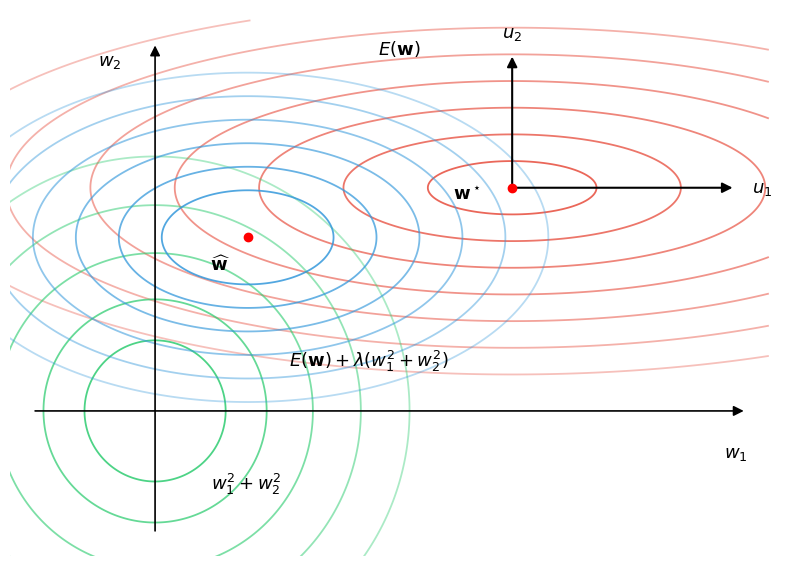

=== ヘッセ行列の固有値と収縮率 ===
方向 w_1 (固有値 eta_1 = 0.35): 未正則化 = 3.20 -> 正則化後 = 0.83 (収縮率: 25.93%)
方向 w_2 (固有値 eta_2 = 3.50): 未正則化 = 2.00 -> 正則化後 = 1.56 (収縮率: 77.78%)

正則化係数 lambda = 1.0 における有効パラメータ数 gamma: 1.037 / 2


In [2]:
# Figure 9.3 の再現とパラメータ収縮の可視化
fig9_3 = generate_figure_9_3()
plt.show()

# 数値的検証: QuadraticObjective クラスを用いた収縮率と有効パラメータ数の計算
H = np.diag([0.35, 3.5])
w_star = np.array([3.2, 2.0])
obj = QuadraticObjective(H=H, w_star=w_star)

print("=== ヘッセ行列の固有値と収縮率 ===")
for i, (eta, w_s) in enumerate(zip(obj.eigenvalues, w_star), 1):
    factor = eta / (eta + 1.0)
    w_h = factor * w_s
    print(f"方向 w_{i} (固有値 eta_{i} = {eta:.2f}): 未正則化 = {w_s:.2f} -> 正則化後 = {w_h:.2f} (収縮率: {factor:.2%})")

print(f"\n正則化係数 lambda = 1.0 における有効パラメータ数 gamma: {obj.effective_number_of_parameters(1.0):.3f} / {len(w_star)}")


---
## 2. 整合的正則化項 (Consistent Regularizers - Section 9.2.1)

### 2.1 ニューラルネットワークの線形変換に対する不変性

単純な重み減衰式 (9.1) の根本的な限界の一つは、**データの線形変換に対するネットワーク写像の等価性を破壊してしまう**ことです。

単一隠れ層（$M$ 個の $\tanh$ ユニット）と線形出力ユニットを持つ 2層パーセプトロンを考えます：
$$
z_j = h\left( \sum_{i} w_{ji} x_i + w_{j0} \right) \tag{9.6}
$$
$$
y_k = \sum_{j} w_{kj} z_j + w_{k0} \tag{9.7}
$$

#### 入力の線形アフィン変換
入力変数に対して次のようなスケール変換およびシフト変換を施したとします：
$$
x_i \to \widetilde{x}_i = a x_i + b \tag{9.8}
$$
このとき、第1層の重みとバイアスを次のように変換すれば、隠れユニットへの入力総和は不変に保たれ、ネットワークの写像関係は一切変化しません：
$$
\widetilde{w}_{ji} = \frac{1}{a} w_{ji} \tag{9.9}
$$
$$
\widetilde{w}_{j0} = w_{j0} - \frac{b}{a} \sum_{i} w_{ji} \tag{9.10}
$$

#### 出力の線形アフィン変換
同様に、目標変数（出力）に対してアフィン変換を施した場合：
$$
y_k \to \widetilde{y}_k = c y_k + d \tag{9.11}
$$
第2層の重みとバイアスを次のように変換すれば、完全に等価なモデルが得られます：
$$
\widetilde{w}_{kj} = c w_{kj} \tag{9.12}
$$
$$
\widetilde{w}_{k0} = c w_{k0} + d \tag{9.13}
$$

### 2.2 なぜ単純な重み減衰は不整合なのか？
式 (9.1) の単純な重み減衰 $\frac{\lambda}{2} \sum w^2$ は、第1層の重み、第2層の重み、およびバイアスをすべて同等に扱っています。
しかし、もし入力の単位を変更（例えばメートルからミリメートルへ、$a = 1000$）すると、等価なネットワークでは重み $w_{ji}$ が $1/1000$ に縮小し、バイアス $w_{j0}$ は大きくシフトします。単純な二乗和ペナルティは、この物理的に等価な2つの表現に対して全く異なるペナルティ値を課してしまい、解を恣意的に偏らせます。

### 2.3 整合性を持つ層別正則化項
線形変換 (9.9), (9.10), (9.12), (9.13) に対する不変性を満たすためには、**バイアスを正則化から除外し**、層ごとに独立した正則化係数を持たせる必要があります：
$$
\Omega(\mathbf{w}) = \frac{\lambda_1}{2} \sum_{w \in \mathcal{W}_1} w^2 + \frac{\lambda_2}{2} \sum_{w \in \mathcal{W}_2} w^2 \tag{9.14}
$$
ここで $\mathcal{W}_1, \mathcal{W}_2$ はそれぞれ第1層、第2層の重み集合（バイアスを除く）です。正則化係数を $\lambda_1 \to a^2 \lambda_1$、$\lambda_2 \to c^{-2} \lambda_2$ とリスケールすることで、正則化項の値は完全に不変に保たれます。

### 2.4 関数空間における事前分布と4つの超パラメータ
正則化項 (9.14) は、パラメータ上の事前分布：
$$
p(\mathbf{w} \mid \alpha_1, \alpha_2) \propto \exp\left( -\frac{\alpha_1}{2} \sum_{w \in \mathcal{W}_1} w^2 - \frac{\alpha_2}{2} \sum_{w \in \mathcal{W}_2} w^2 \right) \tag{9.15}
$$
に対応します。バイアスが無制約であるため、この事前分布は不適切事前分布（Improper Prior）となります。そのため、実際にはバイアスに対しても独立したハイパーパラメータを持つガウス事前分布を設定するのが一般的です。

Bishop & Bishop (2024) では、2層ネットワーク（1入力、1線形出力、12個の $\tanh$ 隠れユニット）について、4つの超パラメータ $(\alpha_1^{\mathrm{w}}, \alpha_1^{\mathrm{b}}, \alpha_2^{\mathrm{w}}, \alpha_2^{\mathrm{b}})$ の役割を事前分布サンプリングによって美しく可視化しています（Figure 9.4）：
1. **$\alpha_2^{\mathrm{w}}$**: 関数の**縦方向のスケール (Vertical Scale)** を支配（第2層の重み振幅）。
2. **$\alpha_1^{\mathrm{w}}$**: 関数の**水平方向の変動スケール (Horizontal Scale of Variations)** を支配（第1層重みが大きいと急峻なステップ関数に変化）。
3. **$\alpha_1^{\mathrm{b}}$**: 水平方向の**変動が生じる範囲 (Horizontal Range)** を支配（バイアスの広がり）。
4. **$\alpha_2^{\mathrm{b}}$**: 関数の**縦方向のオフセット (Vertical Offsets)** を支配。


入力変換に対するネットワーク出力の最大絶対誤差: 4.44e-16 (完全一致)


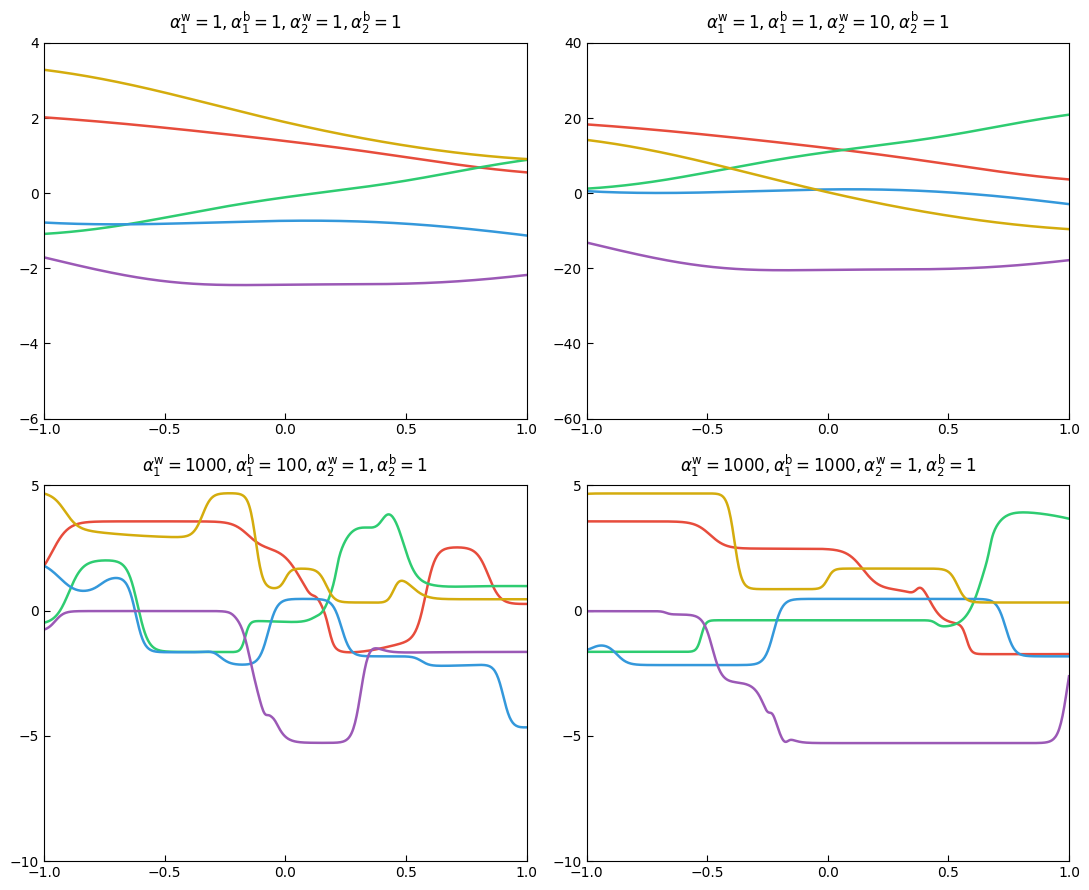

In [3]:
# 2層MLPの線形変換不変性の数値的検証
rng = np.random.RandomState(42)
W1 = rng.randn(6, 1)
b1 = rng.randn(6, 1)
W2 = rng.randn(1, 6)
b2 = rng.randn(1, 1)

mlp = MLP2Layer(W1=W1, b1=b1, W2=W2, b2=b2)

# 入力アフィン変換: x_tilde = 2.5 * x - 1.2
a, b = 2.5, -1.2
mlp_in = mlp.transform_inputs(a=a, b=b)

x_test = np.linspace(-2, 2, 10)
x_trans = a * x_test + b

y_orig = mlp.forward(x_test)
y_trans = mlp_in.forward(x_trans)

max_diff = np.max(np.abs(y_orig - y_trans))
print(f"入力変換に対するネットワーク出力の最大絶対誤差: {max_diff:.2e} (完全一致)")

# Figure 9.4 の再現
fig9_4 = generate_figure_9_4()
plt.show()


---
## 3. 一般化された重み減衰とスパース性 (Generalized Weight Decay - Section 9.2.2)

### 3.1 $L_q$ 正則化の定式化と等高線

2次のペナルティを一般化し、重みの絶対値の $q$ 乗の和を用いた正則化項を考えます：
$$
\Omega(\mathbf{w}) = \frac{\lambda}{2} \sum_{j=1}^{M} |w_j|^q \tag{9.18}
$$
正則化された誤差関数は：
$$
\widetilde{E}(\mathbf{w}) = E(\mathbf{w}) + \frac{\lambda}{2} \sum_{j=1}^{M} |w_j|^q \tag{9.19}
$$
となります。
- $q = 2$: 通常の二次正則化（Ridge / 重み減衰）。
- $q = 1$: 絶対値ペナルティ（Lasso, Tibshirani 1996）。
- $q = 0.5$: 非凸（concave）な星型等高線。
- $q = 4$: 角が丸められた正方形（超楕円）。


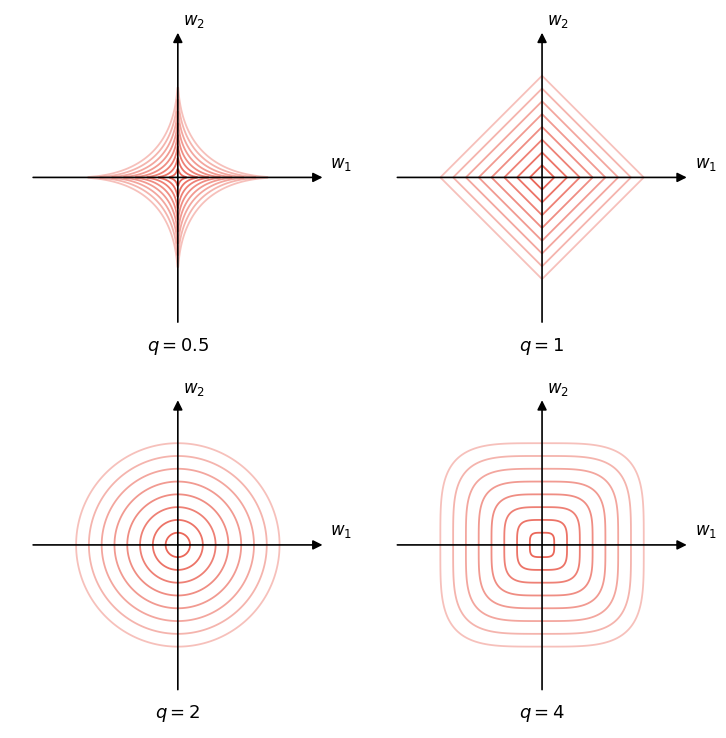

In [4]:
# Figure 9.5 の再現: 様々な q における L_q 正則化項の等高線
fig9_5 = generate_figure_9_5()
plt.show()


### 3.2 スパース性の幾何学的起源 (Lasso vs Ridge)

正則化誤差関数 (9.19) の最小化は、ラグランジュ乗数法を用いることで、次の**不等式制約付き最適化問題**と完全に等価になります：
$$
\min_{\mathbf{w}} E(\mathbf{w}) \quad \text{subject to} \quad \sum_{j=1}^{M} |w_j|^q \le \eta \tag{9.20}
$$
ここで、制約値 $\eta$ は正則化係数 $\lambda$ と 1対1 に対応します（$\lambda$ が大きくなるほど許容領域 $\eta$ は狭くなります）。

#### なぜ Lasso ($q=1$) はスパース解（ゼロ重み）をもたらすのか？
- **Lasso ($q=1$) の制約領域**:
  $\sum |w_j| \le \eta$ は座標軸上に鋭い頂点（角, corner）を持つひし形（$L_1$ 球）を形成します。
  非正則化誤差関数 $E(\mathbf{w})$ の楕円等高線が中心 $\mathbf{w}^\star$ から拡大していくとき、制約領域と最初に接触する接触点 $\widehat{\mathbf{w}}$ は、**高い確率で座標軸上の頂点**になります。
  頂点では他の座標成分が厳密にゼロ（例えば 2次元なら $\widehat{w}_1 = 0$）となり、不要なパラメータが完全に消去された**スパースモデル (Sparse Model)** が得られます。
- **Ridge ($q=2$) の制約領域**:
  $\sum w_j^2 \le \eta$ は滑らかな円（$L_2$ 球）であり、角が存在しません。
  楕円等高線との接点は一般に座標軸から離れた滑らかな面上に位置するため、重みはゼロに向かって縮小するものの、厳密にゼロになることはありません。


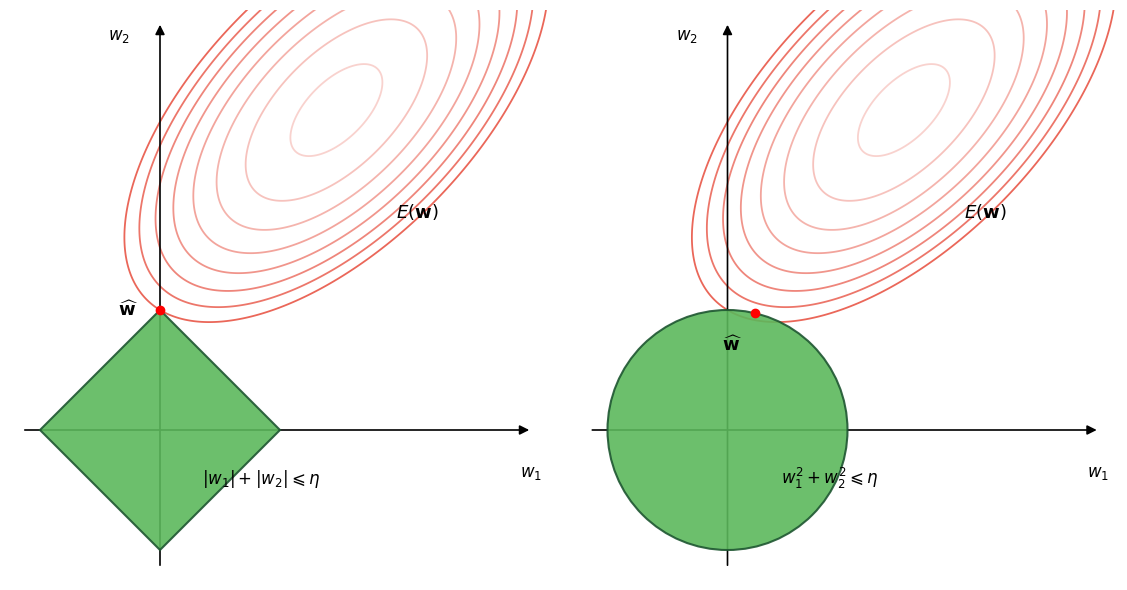

=== 制約付き最適化の厳密解の比較 ===
非正則化最適点 w_star: [1.4700, 2.6660]
Lasso (q=1) 最適点 w_hat: [-0.00000000, 1.00000000]  -> w_1 is EXACTLY ZERO!
Ridge (q=2) 最適点 w_hat: [0.23003230, 0.97318299]  -> w_1 and w_2 are BOTH NON-ZERO!


In [5]:
# Figure 9.6 の再現: Lasso (q=1) と Ridge (q=2) のスパース性比較
fig9_6 = generate_figure_9_6()
plt.show()

# 数値最適化による厳密なスパース性の検証
theta = np.deg2rad(45)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
a, b = 1.4, 0.7
H_inv = R @ np.diag([a**2, b**2]) @ R.T
H = np.linalg.inv(H_inv)
g = np.array([0.6, 1.0])
w_star = np.array([0.0, 1.0]) + H_inv @ g
eta = 1.0

# 制約付き最適化の解を計算
w_hat_lasso = solve_constrained_qp(H=H, w_star=w_star, q=1.0, eta=eta)
w_hat_ridge = solve_constrained_qp(H=H, w_star=w_star, q=2.0, eta=eta)

print("=== 制約付き最適化の厳密解の比較 ===")
print(f"非正則化最適点 w_star: [{w_star[0]:.4f}, {w_star[1]:.4f}]")
print(f"Lasso (q=1) 最適点 w_hat: [{w_hat_lasso[0]:.8f}, {w_hat_lasso[1]:.8f}]  -> w_1 is EXACTLY ZERO!")
print(f"Ridge (q=2) 最適点 w_hat: [{w_hat_ridge[0]:.8f}, {w_hat_ridge[1]:.8f}]  -> w_1 and w_2 are BOTH NON-ZERO!")


---
## 4. まとめと第9.3節への展望

### 本節で学んだ重要概念
1. **重み減衰の幾何学**:
   ヘッセ行列の固有値分解により、曲率（固有値）の小さい不感なパラメータ方向ほど強力にゼロへ収縮し、実効的な自由度 $\gamma$ を削減する。
2. **変換整合性と層別正則化**:
   入力・出力の線形スケーリングやシフトに対する写像不変性を維持するためには、バイアスを除外し、層ごとに異なる正則化係数を設定する必要がある。
3. **4つの超パラメータによる事前関数の制御**:
   $\alpha_2^{\mathrm{w}}$（縦振幅）、$\alpha_1^{\mathrm{w}}$（水平急峻度）、$\alpha_1^{\mathrm{b}}$（水平有効範囲）、$\alpha_2^{\mathrm{b}}$（縦オフセット）がネットワークの関数族の性質を決定づける。
4. **$L_q$ ノルムとスパース性**:
   $q=1$（Lasso）の制約境界が持つ軸上の角（Corner）が、重みを厳密にゼロへ駆動するスパース性の幾何学的要因である。

### 次節への展開
正則化係数 $\lambda$ をハイパーパラメータとして調整する以外に、反復的勾配降下法の学習ステップ数自体を制御することでモデルの実効的複雑さを制限するアプローチが存在します。
次節 **第9.3節「学習曲線 (Learning Curves)」** では、検証データ誤差に基づく**早期終了 (Early Stopping)** と重み減衰の数学的等価性、および過剰適合の現代的理解である**二重降下現象 (Double Descent)** について探求します。
